In [34]:
import copy
import os
import sys

import numpy as np

from scipy import stats

from cliffs_delta import cliffs_delta

from collections import defaultdict

from tqdm import tqdm
import functools, contextlib, os, warnings

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

import torch 

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS.predict import get_prediction
from scLEMBAS.metrics import distances

sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split


In [14]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [15]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

subnetwork = pd.read_csv(
    os.path.join(data_path, 'processed', 'consensus_subnetwork_edges_TGFB1^BasalClub.csv')
)


In [16]:
subnetwork_nodes = sorted(set(subnetwork.source.tolist() + subnetwork.target.tolist()))
subnetwork_tfs = sorted(set(subnetwork_nodes).intersection(tf_adata.var_names))
print('The subnetwork contains {} of {} TFs'.format(len(subnetwork_tfs), tf_adata.n_vars))


The subnetwork contains 183 of 380 TFs


We will assess how well the subnetwork is capable of predicting the 183 intersecting TFs compared to the full network.

In [17]:
n_ensembles = 10
seed_multiplier = 21234

pert = 'TGFB1'
cell_types = ['Basal', 'Club']
conds = [ct + '^' + pert for ct in cell_types]


In [18]:
def load_model(fold, ensemble_idx, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
    if from_trainer:
        if ensemble_idx < n_ensembles - 1:
            fn_trainer =  os.path.join(fn_base + 'trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        else:
            fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')


        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold,
            adversarial_penalty = True,
            randomize = False,
            seed = seed_
        )

        if ensemble_idx < n_ensembles - 1: # +1 of the originally trained model
            fn_mod = os.path.join(fn_base + 'model_actual_ensemble{}.pt'.format(ensemble_idx))
        else:
            fn_mod = os.path.join(fn_base + 'model_actual.pt')

        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer

class suppress_tqdm:
    def __enter__(self):
        # silence prints (stdout)
        self._devnull = open(os.devnull, "w")
        self._redirect = contextlib.redirect_stdout(self._devnull)
        self._redirect.__enter__()

        # silence warnings
        self._warn_ctx = warnings.catch_warnings()
        self._warn_ctx.__enter__()
        warnings.simplefilter("ignore")   # or filter to specific categories

        # silence tqdm bars
        self._orig_init = tqdm.__init__
        tqdm.__init__ = functools.partialmethod(tqdm.__init__, disable=True)
        return self

    def __exit__(self, *args):
        tqdm.__init__ = self._orig_init
        self._warn_ctx.__exit__(*args)
        self._redirect.__exit__(*args)
        self._devnull.close()
        
        
def get_subnetwork_predictions(fold, ensemble_idx, train_barcodes, test_barcodes):

    mod, _ = load_model(fold, ensemble_idx, from_trainer = False)

    with suppress_tqdm():
        tf_adata_predicted = get_prediction(
            mod = mod,
            train_cells = train_barcodes,
            test_cells = test_barcodes,
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert,
            counterfactual = 'perturbation', # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False,
            max_cells = int(5e3),
            return_full = False,
            stim_label_map = None, # special use case for Kang
            check_forward = True,
        )

    mod_alt = copy.deepcopy(mod)
    remove_nodes_idx = [idx for node,idx in mod_alt.node_idx_map.items() if node not in subnetwork_nodes]
    with torch.no_grad():
        mod_alt.signaling_network.bias_mask[remove_nodes_idx] = True
        mod_alt.signaling_network.cat_embeddings_mask[cat_col][:, remove_nodes_idx] = True

        mod_alt.signaling_network.mask[remove_nodes_idx, :] = True   
        mod_alt.signaling_network.mask[:, remove_nodes_idx] = True

        mod_alt.signaling_network.implement_mask()

    with suppress_tqdm():
        tf_adata_predicted_alt = get_prediction(
            mod = mod_alt,
            train_cells = train_barcodes,
            test_cells = test_barcodes,
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert,
            counterfactual = 'perturbation', # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False,
            max_cells = int(5e3),
            return_full = False,
            stim_label_map = None, # special use case for Kang
            check_forward = True,
        )
        
    return tf_adata_predicted, tf_adata_predicted_alt



In [19]:
# for fold in range(5):
#     split = get_split(fold, author)
#     conds_to_test = sorted(set(conds).intersection(split['test_conds']))
#     if len(conds_to_test) != 0:
#         print(fold)
#         print(conds_to_test)


First fold has Club cells in test split, 4th has Basal cells in test split. 

In [8]:
# import random
# import numpy as np

# def set_seed(s):
#     random.seed(s)
#     np.random.seed(s)
#     torch.manual_seed(s)
#     torch.cuda.manual_seed_all(s)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True, warn_only=True)

In [27]:
fn = os.path.join(data_path, 'processed', '{}_subnetwork_comparison.csv'.format(author))
if not os.path.isfile(fn):
    res = defaultdict(list)
    for fold in range(5):
        split = get_split(fold, author)
        conds_to_test = sorted(set(conds).intersection(split['test_conds']))

        if len(conds_to_test) == 0:
            continue

        assert len(conds_to_test) == 1, 'Expected only one or zero relevant test condition per fold'

        train_barcodes = split['train_barcodes']
        test_barcodes = split['test_barcodes']

        test_cond_mask = tf_adata[test_barcodes, :].obs.condition.isin(conds_to_test)
        test_barcodes = test_cond_mask[test_cond_mask].index.tolist()

        for ensemble_idx in tqdm(range(n_ensembles)):
    #         set_seed(seed + fold * 1000 + ensemble_idx)

            tf_adata_predicted_full, tf_adata_predicted_sub = get_subnetwork_predictions(fold, ensemble_idx, train_barcodes, test_barcodes)

            emd_loss_full = distances.get_EMD_loss(tf_adata[:, subnetwork_tfs], tf_adata_predicted_full[:, subnetwork_tfs])['Mean EMD Loss']
            emd_loss_sub = distances.get_EMD_loss(tf_adata[:, subnetwork_tfs], tf_adata_predicted_sub[:, subnetwork_tfs])['Mean EMD Loss']

            res['emd_loss_full'].append(emd_loss_full)
            res['emd_loss_sub'].append(emd_loss_sub)
            res['fold'].append(fold)
            res['ensemble_idx'].append(ensemble_idx)
            res['test_condition'].append(conds_to_test[0])
    res = pd.DataFrame(res)
    res.to_csv(fn)
    
else:
    res = pd.read_csv(fn, index_col = 0)


In [28]:
mod, _ = load_model(fold, ensemble_idx, from_trainer = False)


mod_alt = copy.deepcopy(mod)
remove_nodes_idx = [idx for node,idx in mod_alt.node_idx_map.items() if node not in subnetwork_nodes]
with torch.no_grad():
    mod_alt.signaling_network.bias_mask[remove_nodes_idx] = True
    mod_alt.signaling_network.cat_embeddings_mask[cat_col][:, remove_nodes_idx] = True

    mod_alt.signaling_network.mask[remove_nodes_idx, :] = True   
    mod_alt.signaling_network.mask[:, remove_nodes_idx] = True

    mod_alt.signaling_network.implement_mask()
    
n_edges_cghanged = mod_alt.signaling_network.mask.sum().item() - mod.signaling_network.mask.sum().item()
print('The subnetwork model has {} fewer edges'.format(n_edges_cghanged))


The subnetwork model has 10968 fewer edges


Visualize:

In [29]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

In [30]:
a,b = res.emd_loss_full, res.emd_loss_sub
cd = cohens_d_paired(a,b)
pval = stats.wilcoxon(a, b).pvalue

viz_df = pd.melt(res[['emd_loss_full', 'emd_loss_sub']], var_name='Model Type', value_name='EMD Loss')
viz_df['Model Type'] = pd.Categorical(
    viz_df['Model Type'].apply(lambda x: x.split('emd_loss_')[1].capitalize()).replace('Sub', 'Subnetwork'), 
    categories = ['Full', 'Subnetwork'], 
    ordered = True
)

In [31]:
pval

0.01068878173828125

In [32]:
np.median(a)

37.65039825439453

In [33]:
np.median(b)

38.16436004638672

In [34]:
np.mean(a)

36.80849380493164

In [35]:
np.mean(b)

37.592978191375735

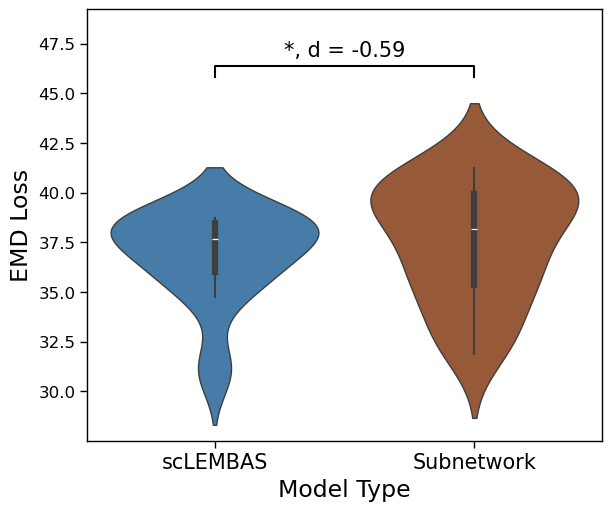

In [37]:
# helper for the significance bracket
def _sig_stars(p):
    if p < 1e-4:  return "****"
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 5e-2:  return "*"
    return "ns"

viz_df['Model Type'] = viz_df['Model Type'].replace({'Full': 'scLEMBAS'})
palette = {'scLEMBAS': "#377eb8", 'Subnetwork': "#a65628"}

with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 17,
        "axes.titlesize": 16,
        "legend.fontsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 12,
    }
):
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

    sns.violinplot(data=viz_df, x='Model Type', y='EMD Loss', ax=ax,
                   hue='Model Type', palette=palette, legend=False)

    ax.set_ylabel('EMD Loss')
    ax.set_xlabel('Model Type')

    # --- significance bracket: stars + Cohen's d on the same line ---
    y_lo, y_hi = ax.get_ylim()
    span = y_hi - y_lo
    bar_y = y_hi + span * 0.06        # bracket sits above the violins
    tick = span * 0.03                # end-cap drop
    vx1, vx2 = 0, 1                   # violin x-positions

    ax.plot(
        [vx1, vx1, vx2, vx2],
        [bar_y - tick, bar_y, bar_y, bar_y - tick],
        lw=1.5, c="black", clip_on=False,
    )
    ax.text(
        (vx1 + vx2) / 2.0, bar_y + span * 0.015,
        "{}, d = {:.2f}".format(_sig_stars(pval), cd),
        ha="center", va="bottom", fontsize=15,
    )
    ax.set_ylim(y_lo, bar_y + span * 0.16)
    fig.savefig(os.path.join(data_path, 'figures', '{}_subnetwork_comparison.png'.format(author)), 
                             dpi=600, bbox_inches='tight', transparent=True)

    plt.show()
    

Significant with medium effect size (especially compared to baseline models), but a reasonable change in loss especially compared to baseline performance discrepancies.